In [ ]:
import os
import sys
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

import matplotlib.pyplot as plt

torch.manual_seed(8008135)

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

CODE_DIR = Path("/content/drive/MyDrive/HRM_Reconstruction")

assert CODE_DIR.exists(), f"Path does not exist: {CODE_DIR}"
print("CODE_DIR:", CODE_DIR)
print("CODE_DIR contents:", os.listdir(CODE_DIR))

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

code_path = str(CODE_DIR / "code")
if code_path not in sys.path:
    sys.path.insert(0, code_path)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device set to {device}")

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

In [5]:
import os
path = "/content/drive/MyDrive/hrm_best_34M.pt"
print("Exists:", os.path.exists(path))

Exists: True


In [ ]:
from data.Datasets.Sudoku_DataLoader import get_loaders

from HRM_Model.HRM_Model import HRM_ACT
from HRM_Model.HRM_Components import Encoder, HighLevel, LowLevel, Head, QHead
from HRM_Model.HRM_ACT_Train import train_hrm_act, evaluate_hrm_act

from Utils.schedules import cosine_schedule_with_warmup_lr_lambda
from Utils.checkpointing import load_checkpoint

In [ ]:
train_size = 2**11   # 2048 samples
test_size  = 2**9    # 512 samples
batch_size = 2**7

train_dataloader, val_dataloader = get_loaders(
    train_size=train_size,
    test_size=test_size,
    batch_size=batch_size,
)

In [ ]:
d_model = 512
M_max = 8
N = 2
T = 2
n_layers = 4
n_heads = 8
vocab_size = 10
dropout = 0.2
epsilon = 0.1

lr = 5e-5
min_lr_ratio = 0.1
lr_warmup = 0.05
beta1 = 0.9
beta2 = 0.95
weight_decay = 0.1
num_epochs = 3

checkpoint_dir = "checkpoints_act"
pretrained_path = "/content/drive/MyDrive/hrm_best_34M.pt"

In [ ]:
high_level = HighLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

low_level = LowLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

encoder = Encoder(
    vocab_size=vocab_size,
    d_model=d_model,
)

head = Head(
    d_model=d_model,
    vocab_size=vocab_size,
)

q_head = QHead(
    d_model=d_model,
)

HRM_ACT_model = HRM_ACT(
    L_module=low_level,
    H_module=high_level,
    encoder=encoder,
    head=head,
    q_head=q_head,
    M=M_max,
    N=N,
    T=T,
    max_len=81,
    d_model=d_model,
    epsilon=epsilon,
).to(device)

if pretrained_path is not None and os.path.exists(pretrained_path):
    ckpt = torch.load(pretrained_path, map_location=device)
    state = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    missing, unexpected = HRM_ACT_model.load_state_dict(state, strict=False)
    print(f"Loaded pretrained backbone from {pretrained_path}")
    print(f"Missing keys: {missing}")
    print(f"Unexpected keys: {unexpected}")
else:
    print("Training ACT from scratch")

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in HRM_ACT_model.parameters() if p.requires_grad):,}",
)

In [ ]:
optimizer = optim.AdamW(
    HRM_ACT_model.parameters(),
    lr=lr,
    betas=(beta1, beta2),
    weight_decay=weight_decay,
)

num_training_steps = len(train_dataloader) * num_epochs * M_max
num_warmup_steps = int(lr_warmup * num_training_steps)

scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_schedule_with_warmup_lr_lambda(
        step,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
        min_ratio=min_lr_ratio,
    ),
)

print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)

In [ ]:
HRM_ACT_model, best_metric, history = train_hrm_act(
    model=HRM_ACT_model,
    train_loader=train_dataloader,
    optimizer=optimizer,
    loss_fn=nn.CrossEntropyLoss(ignore_index=-100),
    device=device,
    scheduler=scheduler,
    num_epochs=num_epochs,
    M_max=M_max,
    checkpoint_dir=checkpoint_dir,
    checkpoint_every=1,
    validate_every=1,
    val_loader=val_dataloader,
)

HRM_ACT_model.eval()

print("Best ACT val board accuracy:", best_metric)

In [ ]:
train_steps = history["step"]
train_loss = history["train_loss"]
ce = history["ce"]
bce = history["bce"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, ce, label="CE", linewidth=1)
axes[0].plot(train_steps, bce, label="BCE (Q-head)", linewidth=1)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].set_title("ACT Loss Components")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_steps, history["mean_m_at_halt"], label="mean M at halt", linewidth=1)
axes[1].plot(train_steps, history["halt_acc"], label="halt accuracy", linewidth=1)
axes[1].axhline(M_max, color="red", linestyle="--", alpha=0.5, label=f"M_max={M_max}")
axes[1].set_xlabel("Training step")
axes[1].set_title("ACT Halt Behaviour")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
HRM_ACT_model.eval()

print(f"{'M_max':>6} | {'token_acc':>10} | {'board_acc':>10} | {'mean_m':>7}")
print("-" * 45)

for mmax in [2, 4, 8, 16]:
    tok, board, mean_m = evaluate_hrm_act(
        HRM_ACT_model,
        val_dataloader,
        device,
        M_max=mmax,
    )
    print(f"{mmax:>6} | {tok * 100:>9.2f}% | {board * 100:>9.2f}% | {mean_m:>7.2f}")

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from HRM_Model.HRM_Train import evaluate_hrm

m_values = [2, 4, 8, 16]
fixed_results = []
act_results = []
original_M = HRM_ACT_model.M

# Fixed-M sweep — ignores Q-head, always runs M segments
for m in m_values:
    HRM_ACT_model.M = m
    _, tok, board = evaluate_hrm(
        HRM_ACT_model, val_dataloader,
        nn.CrossEntropyLoss(ignore_index=-100), device,
    )
    fixed_results.append((m, board * 100, m))
    print(f"Fixed M={m}: board={board*100:.2f}%")

# ACT sweep — uses Q-head halt rule with budget M_max
for m_max in m_values:
    tok, board, mean_m = evaluate_hrm_act(
        HRM_ACT_model, val_dataloader, device, M_max=m_max,
    )
    act_results.append((m_max, board * 100, mean_m))
    print(f"ACT M_max={m_max}: board={board*100:.2f}% (mean compute={mean_m:.2f})")

HRM_ACT_model.M = original_M


In [ ]:
import matplotlib.pyplot as plt

ACT_RED      = "#DA6A6A"
NEUTRAL_GRAY = "#8E8E8E"
DARK         = "#1F1F1F"

fixed_x = [r[0] for r in fixed_results]
fixed_y = [r[1] for r in fixed_results]
fixed_c = [r[2] for r in fixed_results]

act_x = [r[0] for r in act_results]
act_y = [r[1] for r in act_results]
act_c = [r[2] for r in act_results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel (a): compute spent
axes[0].plot(fixed_x, fixed_c, "s--", color=NEUTRAL_GRAY, linewidth=1.8, markersize=7,
             label="Fixed-M compute")
axes[0].plot(act_x, act_c, "o-", color=ACT_RED, linewidth=2.5, markersize=9,
             label="ACT mean compute")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(fixed_x)
axes[0].set_xticklabels(fixed_x)
axes[0].set_xlabel(r"$M$ (Fixed) or $M_{\max}$ (ACT)", color=DARK)
axes[0].set_ylabel("Mean compute steps", color=DARK)
axes[0].set_title("(a) ACT Compute Spent", fontweight="bold", color=DARK)
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Panel (b): board accuracy — same model, two inference strategies
axes[1].plot(fixed_x, fixed_y, "s--", color=NEUTRAL_GRAY, linewidth=1.8, markersize=7,
             label="Fixed-M (same model)")
axes[1].plot(act_x, act_y, "o-", color=ACT_RED, linewidth=2.5, markersize=9,
             label="ACT (same model)")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(fixed_x)
axes[1].set_xticklabels(fixed_x)
axes[1].set_xlabel(r"Inference $M$ or $M_{\max}$", color=DARK)
axes[1].set_ylabel("Board accuracy (%)", color=DARK)
axes[1].set_title("(b) Inference-time Scaling", fontweight="bold", color=DARK)
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("act_apples.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

ACT_RED      = "#DA6A6A"
NEUTRAL_GRAY = "#8E8E8E"
DARK         = "#1F1F1F"

N_my = 2  # because the model uses N=2

# Multiply M values and compute values by N to normalize to N=1 convention
fixed_x = [r[0] * N_my for r in fixed_results]   # was r[0]
fixed_y = [r[1] for r in fixed_results]
fixed_c = [r[2] * N_my for r in fixed_results]   # was r[2]

act_x = [r[0] * N_my for r in act_results]       # was r[0]
act_y = [r[1] for r in act_results]
act_c = [r[2] * N_my for r in act_results]       # was r[2]


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel (a): compute spent
axes[0].plot(fixed_x, fixed_c, "s--", color=NEUTRAL_GRAY, linewidth=1.8, markersize=8,
             label="Fixed-M compute")
axes[0].plot(act_x, act_c, "o-", color=ACT_RED, linewidth=2.5, markersize=9,
             label="ACT mean compute")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(fixed_x); axes[0].set_xticklabels(fixed_x)
axes[0].set_xlabel(r"$M$ (Fixed) or $M_{\max}$ (ACT)", color=DARK)
axes[0].set_ylabel("Mean compute steps", color=DARK)
axes[0].set_title("(a) ACT Compute Spent", fontweight="bold", color=DARK)
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

# Panel (b): both visible via layered markers
axes[1].plot(fixed_x, fixed_y, "s--", color=NEUTRAL_GRAY,
             linewidth=2.2, markersize=14, alpha=0.95,
             label="Fixed-M", zorder=2)
axes[1].plot(act_x, act_y, "o-", color=ACT_RED,
             linewidth=1.8, markersize=7, alpha=0.95,
             markeredgecolor="white", markeredgewidth=1.5,
             label="ACT", zorder=3)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(fixed_x); axes[1].set_xticklabels(fixed_x)
axes[1].set_xlabel(r"Inference $M$ or $M_{\max}$", color=DARK)
axes[1].set_ylabel("Board accuracy (%)", color=DARK)
axes[1].set_title("(b) Inference-time Scaling", fontweight="bold", color=DARK)
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False, loc="lower right")
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)

axes[1].text(
    0.03, 0.97,
    "Lines overlap: 100% agreement",
    transform=axes[1].transAxes,
    ha="left", va="top",
    fontsize=9, color=DARK,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="none", edgecolor=NEUTRAL_GRAY, alpha=0.9),
)

fig.text(
    0.5, -0.02,
    "Takeaway: ACT halts each puzzle at its own convergence point (easy ones stop at 2 steps, hard ones use the full 16) matching fixed-M accuracy with ~3× less average compute.",
    ha="center", va="top",
    fontsize=10, fontweight="bold", color=DARK,
    wrap=True,
)

plt.tight_layout()

fig.patch.set_alpha(0.0)
for ax in axes:
    ax.patch.set_alpha(0.0)

plt.savefig(
    "act_apples.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3,
    transparent=True,
    facecolor="none",
    edgecolor="none",
)

plt.show()


In [ ]:
@torch.no_grad()
def compare_fixed_vs_act(model, val_loader, device, M_max):
    model.eval()
    fixed_correct, act_correct, agreements, m_used_list = [], [], [], []
    original_M = model.M

    for x, y in val_loader:
        x = x.to(device); y = y.to(device)

        # Fixed-M
        model.M = M_max
        z_H, z_L = None, None
        for _ in range(M_max):
            z_H, z_L, logits = model.segment(x, z_H, z_L)
            z_H = z_H.detach(); z_L = z_L.detach()
        fixed_pred = logits.argmax(dim=-1)
        fixed_filled = torch.where(x != 0, x, fixed_pred)

        # ACT
        act_filled, m_used = model.predict_act(x, M_max=M_max)

        fixed_correct.append((fixed_filled == y).all(dim=1))
        act_correct.append((act_filled == y).all(dim=1))
        agreements.append((fixed_filled == act_filled).all(dim=1))
        m_used_list.append(m_used)

    model.M = original_M

    fc = torch.cat(fixed_correct); ac = torch.cat(act_correct)
    ag = torch.cat(agreements); mu = torch.cat(m_used_list)

    print(f"\nM_max = {M_max}")
    print(f"  Fixed-M correct: {fc.float().mean()*100:.2f}%")
    print(f"  ACT correct:     {ac.float().mean()*100:.2f}%")
    print(f"  Per-sample agreement: {ag.float().mean()*100:.2f}%  (= fraction with identical predictions)")
    print(f"  Mean m_used: {mu.float().mean().item():.2f}")
    print(f"  m_used histogram:")
    for m in range(1, M_max + 1):
        cnt = (mu == m).sum().item()
        if cnt > 0:
            print(f"    m={m}: {cnt} samples ({cnt/len(mu)*100:.1f}%)")

for mmax in [2, 4, 8, 16]:
    compare_fixed_vs_act(HRM_ACT_model, val_dataloader, device, mmax)


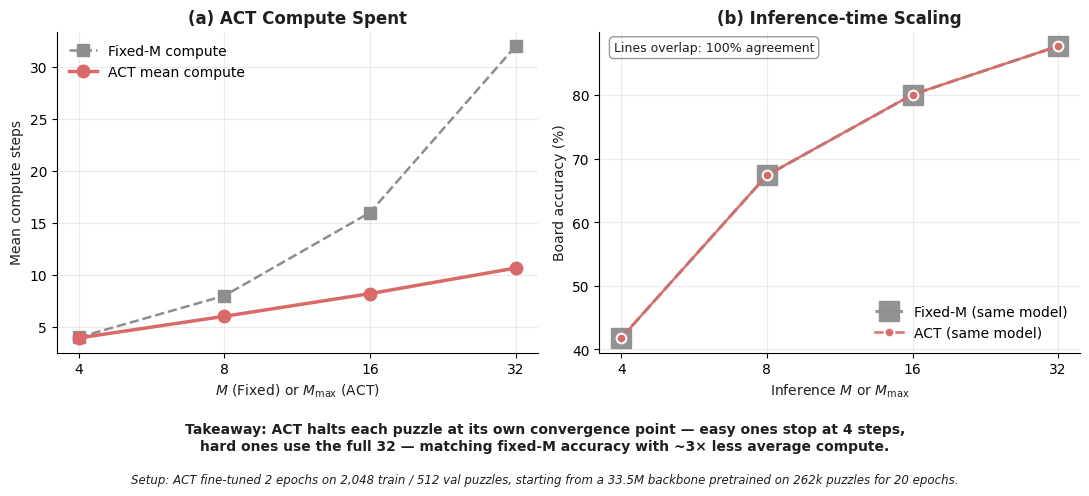

In [8]:
import matplotlib.pyplot as plt

ACT_RED      = "#DA6A6A"
NEUTRAL_GRAY = "#8E8E8E"
DARK         = "#1F1F1F"

# Hardcoded results from your sweep
fixed_results = [
    (2, 41.80, 2),
    (4, 67.38, 4),
    (8, 80.08, 8),
    (16, 87.70, 16),
]

act_results = [
    (2, 41.80, 1.97),
    (4, 67.38, 3.01),
    (8, 80.08, 4.10),
    (16, 87.70, 5.33),
]

N_my = 2  # normalize to N=1 convention

fixed_x = [r[0] * N_my for r in fixed_results]
fixed_y = [r[1] for r in fixed_results]
fixed_c = [r[2] * N_my for r in fixed_results]

act_x = [r[0] * N_my for r in act_results]
act_y = [r[1] for r in act_results]
act_c = [r[2] * N_my for r in act_results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel (a): compute spent
axes[0].plot(fixed_x, fixed_c, "s--", color=NEUTRAL_GRAY, linewidth=1.8, markersize=8,
             label="Fixed-M compute")
axes[0].plot(act_x, act_c, "o-", color=ACT_RED, linewidth=2.5, markersize=9,
             label="ACT mean compute")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(fixed_x); axes[0].set_xticklabels(fixed_x)
axes[0].set_xlabel(r"$M$ (Fixed) or $M_{\max}$ (ACT)", color=DARK)
axes[0].set_ylabel("Mean compute steps", color=DARK)
axes[0].set_title("(a) ACT Compute Spent", fontweight="bold", color=DARK)
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

# Panel (b): board accuracy with both lines visible
axes[1].plot(fixed_x, fixed_y, "s--", color=NEUTRAL_GRAY,
             linewidth=2.2, markersize=14, alpha=0.95,
             label="Fixed-M (same model)", zorder=2)
axes[1].plot(act_x, act_y, "o-", color=ACT_RED,
             linewidth=1.8, markersize=7, alpha=0.95,
             markeredgecolor="white", markeredgewidth=1.5,
             label="ACT (same model)", zorder=3)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(fixed_x); axes[1].set_xticklabels(fixed_x)
axes[1].set_xlabel(r"Inference $M$ or $M_{\max}$", color=DARK)
axes[1].set_ylabel("Board accuracy (%)", color=DARK)
axes[1].set_title("(b) Inference-time Scaling", fontweight="bold", color=DARK)
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False, loc="lower right")
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)

axes[1].text(
    0.03, 0.97,
    "Lines overlap: 100% agreement",
    transform=axes[1].transAxes,
    ha="left", va="top",
    fontsize=9, color=DARK,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="none", edgecolor=NEUTRAL_GRAY, alpha=0.9),
)

fig.text(
    0.5, -0.02,
    "Takeaway: ACT halts each puzzle at its own convergence point — easy ones stop at 4 steps,\nhard ones use the full 32 — matching fixed-M accuracy with ~3× less average compute.",
    ha="center", va="top",
    fontsize=10, fontweight="bold", color=DARK,
)

fig.text(
    0.5, -0.14,
    "Setup: ACT fine-tuned 2 epochs on 2,048 train / 512 val puzzles, starting from a 33.5M backbone pretrained on 262k puzzles for 20 epochs.",
    ha="center", va="top",
    fontsize=8.5, color=DARK, style="italic",
)
plt.tight_layout()

fig.patch.set_alpha(0.0)
for ax in axes:
    ax.patch.set_alpha(0.0)

plt.savefig("act_apples.png", dpi=300, bbox_inches="tight",
            pad_inches=0.5, transparent=True,
            facecolor="none", edgecolor="none")
plt.show()
